# Series de tiempo: Predicción del Precio de Cierre de AMD
## RNN vs LSTM

**Integrante:**
- Christopher Andres Obando Rivera

**Dataset:** AMD (Advanced Micro Devices) — Precio de cierre 2020–2024  
**Objetivo:** Entrenar y comparar 12 configuraciones de redes neuronales recurrentes

---
### Estructura del notebook
1. Instalación e importaciones  
2. Carga y preprocesamiento de datos  
3. Normalización y división temporal  
4. Funciones auxiliares (secuencias, modelos)  
5. Entrenamiento de todos los modelos  
6. Evaluación con MAE y R²  
7. Visualizaciones (predicciones, curvas de pérdida, comparativa)  
8. Análisis interpretativo de resultados


## 1. Instalación e Importaciones

In [ ]:
# !pip install yfinance tensorflow scikit-learn pandas numpy matplotlib

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

# ── Configuración global de reproducibilidad ─────────────────────────────────
SEED = 1007272482
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Silenciar logs de TensorFlow (0=all, 1=info, 2=warn, 3=error)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

## 2. Carga de Datos


In [ ]:
import yfinance as yf

TICKER = "AMD"
START  = "2020-01-01"
END    = "2024-12-31"

try:
    df_raw = yf.download(TICKER, start=START, end=END, interval="1d", progress=False)
    if df_raw.empty:
        raise ValueError("Descarga vacía")
    df = df_raw[['Close']].copy()
    df.index = pd.to_datetime(df.index)
    df.dropna(inplace=True)
    print("Datos descargados desde yfinance")
except Exception as e:
    print(f"yfinance no disponible ({e}). Usando serie sintética GBM.")
    np.random.seed(SEED)
    dates = pd.bdate_range(start=START, end=END)
    price, prices = 50.0, []
    for _ in dates:
        price *= np.exp(np.random.normal(0.0008, 0.025))
        prices.append(price)
    prices = np.array(prices) * (185 / max(prices))
    df = pd.DataFrame({'Close': np.maximum(prices, 5)}, index=dates)
    df.index.name = 'Date'

print(f"Shape        : {df.shape}")
print(f"Rango fechas : {df.index[0].date()} → {df.index[-1].date()}")
df.head()


Datos descargados desde yfinance
Shape        : (1257, 1)
Rango fechas : 2020-01-02 → 2024-12-30


Price,Close
Ticker,AMD
Date,
2020-01-02,49.099998
2020-01-03,48.599998
2020-01-06,48.389999
2020-01-07,48.250000
2020-01-08,47.830002


## 3. Análisis Exploratorio

=== Estadísticas Descriptivas ===
Price         Close
Ticker          AMD
count   1257.000000
mean     103.636714
std       36.012102
min       38.709999
25%       78.879997
50%       96.279999
75%      127.029999
max      211.380005


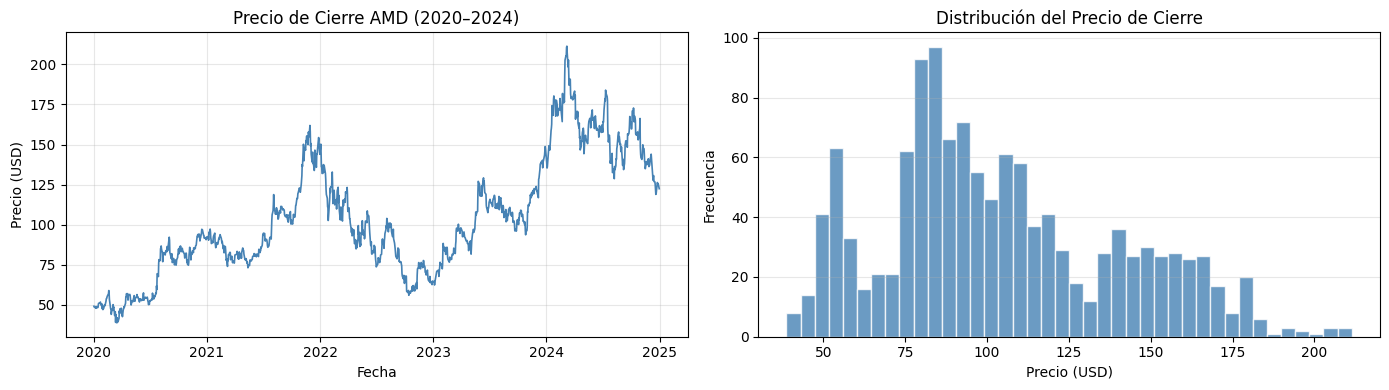

In [ ]:
print("=== Estadísticas Descriptivas ===")
print(df.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Serie temporal completa
axes[0].plot(df.index, df['Close'], color='steelblue', lw=1.2)
axes[0].set_title(f"Precio de Cierre {TICKER} ({START[:4]}–{END[:4]})")
axes[0].set_xlabel("Fecha"); axes[0].set_ylabel("Precio (USD)")
axes[0].grid(alpha=0.3)

# Distribución
axes[1].hist(df['Close'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title("Distribución del Precio de Cierre")
axes[1].set_xlabel("Precio (USD)"); axes[1].set_ylabel("Frecuencia")
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("fig0_eda.png", dpi=150)
plt.show()


## 4. Normalización y División Temporal

**Decisiones metodológicas:**
- `MinMaxScaler` se ajusta solo con datos de entrenamiento para evitar data leakage
- División 80/20 respetando el orden cronológico

Total  :  1257 registros
Train  :  1005 (2020-01-02 → 2023-12-28)
Test   :   252  (2023-12-29 → 2024-12-30)


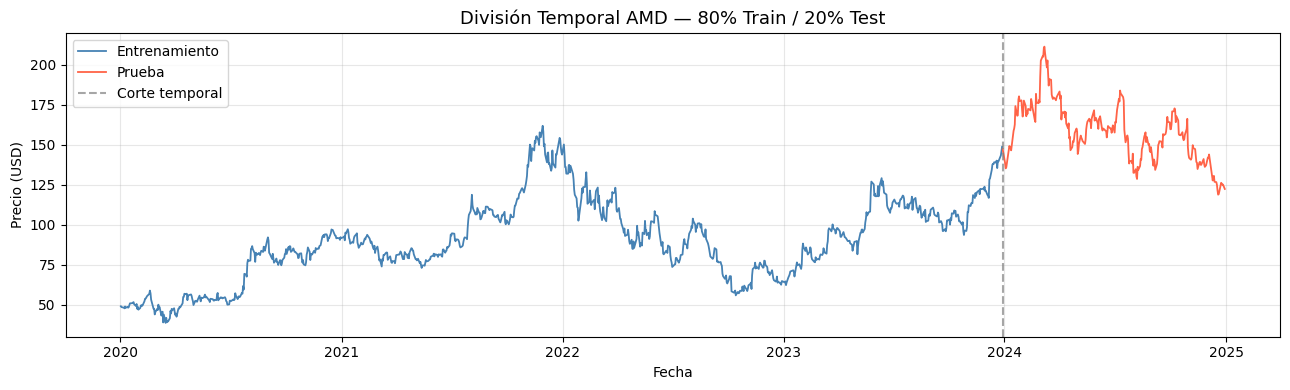

In [ ]:
# Normalización
scaler = MinMaxScaler(feature_range=(0, 1))

split_idx = int(len(df) * 0.80)
train = df.iloc[:split_idx].copy()
test  = df.iloc[split_idx:].copy()

# Ajustar el scaler únicamente con los datos de entrenamiento
train['Close_scaled'] = scaler.fit_transform(train[['Close']])
test['Close_scaled']  = scaler.transform(test[['Close']])

print(f"Total  : {len(df):>5} registros")
print(f"Train  : {len(train):>5} ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test   : {len(test):>5}  ({test.index[0].date()} → {test.index[-1].date()})")

# Visualización de la división
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train.index, train['Close'], color='steelblue', lw=1.3, label='Entrenamiento')
ax.plot(test.index,  test['Close'],  color='tomato',    lw=1.3, label='Prueba')
ax.axvline(x=test.index[0], color='gray', ls='--', alpha=0.7, label='Corte temporal')
ax.set_title(f"División Temporal {TICKER} — 80% Train / 20% Test", fontsize=13)
ax.set_xlabel("Fecha"); ax.set_ylabel("Precio (USD)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig1_division_temporal.png", dpi=150)
plt.show()


## 5. Funciones Auxiliares

### 5.1 Creación de secuencias

Para convertir la serie temporal en un problema de aprendizaje supervisado se usa una **ventana deslizante** de tamaño `time_step`:

```
[t-ts, …, t-1]  →  y[t]
```

### 5.2 Construcción de modelos

Arquitectura mínima: una capa recurrente (SimpleRNN o LSTM) + una capa Dense de salida. Esta simplicidad es intencional: el objetivo es comparar el efecto del `time_step` y el número de neuronas, no optimizar la arquitectura.

In [ ]:
def create_sequences(series: np.ndarray, time_step: int):
    """
    Convierte una serie 1D en pares (X, y) usando ventana deslizante.

    Parámetros
    ----------
    series    : array 1D normalizado
    time_step : longitud de la ventana de contexto

    Retorna
    -------
    X : array (n_samples, time_step)
    y : array (n_samples,)
    """
    X, y = [], []
    for i in range(len(series) - time_step):
        X.append(series[i : i + time_step])
        y.append(series[i + time_step])
    return np.array(X), np.array(y)


def build_model(model_type: str, time_step: int, units: int) -> Sequential:
    """
    Construye y compila un modelo SimpleRNN o LSTM de una sola capa.

    Parámetros
    ----------
    model_type : 'SimpleRNN' | 'LSTM'
    time_step  : longitud de la secuencia de entrada
    units      : número de neuronas en la capa recurrente

    Retorna
    -------
    Modelo Keras compilado con optimizador Adam y pérdida MSE.
    """
    model = Sequential(name=f"{model_type}_ts{time_step}_u{units}")

    if model_type == 'SimpleRNN':
        # activation='tanh' es el estándar; evita ReLU en RNNs por riesgo de exploding gradients
        model.add(SimpleRNN(units, activation='tanh', input_shape=(time_step, 1)))
    elif model_type == 'LSTM':
        model.add(LSTM(units, input_shape=(time_step, 1)))
    else:
        raise ValueError(f"Tipo de modelo desconocido: {model_type}")

    model.add(Dense(1))  # salida escalar: precio del siguiente día
    model.compile(optimizer='adam', loss='mse')
    return model


## 6. Entrenamiento de los 12 Modelos

### Configuraciones experimentales

| time_step | Neuronas (config A) | Neuronas (config B) |
|-----------|--------------------|-----------------|
| 5  | 5  | 10 |
| 10 | 10 | 20 |
| 15 | 15 | 30 |

**Hiperparámetros de entrenamiento:**
- Optimizador: Adam (lr=0.001 por defecto)
- Función de pérdida: MSE
- Máx. épocas: 60
- `EarlyStopping` con patience=10 (restaura los mejores pesos)
- Validation split: 10% del training (temporal implícito en Keras → últimos registros)

In [ ]:
# Hiperparámetros globales
EPOCHS    = 60
BATCH     = 32
PATIENCE  = 10

# Configuraciones a evaluar
CONFIGS      = [(5, 5), (5, 10), (10, 10), (10, 20), (15, 15), (15, 30)]
MODEL_TYPES  = ['SimpleRNN', 'LSTM']

# Almacenamiento de resultados
results       = []      # métricas finales
all_histories = {}      # historial de pérdidas por modelo
all_preds     = {}      # predicciones y valores reales por modelo

# Arrays de trabajo
train_scaled = train['Close_scaled'].values
test_scaled  = test['Close_scaled'].values

# Loop principal de entrenamiento
for model_type in MODEL_TYPES:
    print(f"\n{'='*60}")
    print(f"  MODELO: {model_type}")
    print(f"{'='*60}")

    for time_step, units in CONFIGS:
        key = f"{model_type}_ts{time_step}_u{units}"
        print(f"\n   {key}")

        # ── Crear secuencias de entrenamiento ─────────────────────────────
        X_train, y_train = create_sequences(train_scaled, time_step)
        X_train = X_train.reshape(-1, time_step, 1)

        # ── Crear secuencias de prueba ────────────────────────────────────
        # Se concatenan los últimos `time_step` del train para poder generar
        # el primer vector de contexto del conjunto de prueba (sin leakage)
        combined = np.concatenate([train_scaled[-time_step:], test_scaled])
        X_test, y_test = create_sequences(combined, time_step)
        X_test = X_test.reshape(-1, time_step, 1)

        # ── Construir y entrenar modelo ───────────────────────────────────
        tf.random.set_seed(SEED)
        model = build_model(model_type, time_step, units)

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=0,
        )

        history = model.fit(
            X_train, y_train,
            epochs=EPOCHS,
            batch_size=BATCH,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=0,
        )

        # ── Predicción e inversión de escala ─────────────────────────────
        y_pred_scaled = model.predict(X_test, verbose=0).flatten()
        y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        y_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

        # ── Métricas ──────────────────────────────────────────────────────
        mae = mean_absolute_error(y_real, y_pred)
        r2  = r2_score(y_real, y_pred)
        n_epochs = len(history.history['loss'])

        print(f"    MAE = {mae:.4f} USD  |  R² = {r2:.4f}  |  Épocas = {n_epochs}")

        # ── Guardar resultados ────────────────────────────────────────────
        results.append({
            'Modelo': model_type, 'time_step': time_step,
            'Neuronas': units, 'MAE': round(mae, 4),
            'R2': round(r2, 4), 'Épocas': n_epochs,
        })
        all_histories[key] = history.history
        all_preds[key] = {
            'y_real': y_real,
            'y_pred': y_pred,
            'dates':  test.index[-len(y_real):],
        }

results_df = pd.DataFrame(results)
print("Entrenamiento completado. Modelos entrenados:", len(results_df))



  MODELO: SimpleRNN

  ▶ SimpleRNN_ts5_u5
    MAE = 14.4637 USD  |  R² = 0.0712  |  Épocas = 60

  ▶ SimpleRNN_ts5_u10
    MAE = 14.9695 USD  |  R² = -0.0540  |  Épocas = 60

  ▶ SimpleRNN_ts10_u10


    MAE = 7.6355 USD  |  R² = 0.7182  |  Épocas = 60

  ▶ SimpleRNN_ts10_u20


    MAE = 4.5073 USD  |  R² = 0.8947  |  Épocas = 60

  ▶ SimpleRNN_ts15_u15
    MAE = 6.5991 USD  |  R² = 0.7906  |  Épocas = 60

  ▶ SimpleRNN_ts15_u30
    MAE = 5.1440 USD  |  R² = 0.8662  |  Épocas = 60

  MODELO: LSTM

  ▶ LSTM_ts5_u5
    MAE = 7.1323 USD  |  R² = 0.7445  |  Épocas = 60

  ▶ LSTM_ts5_u10
    MAE = 5.6115 USD  |  R² = 0.8416  |  Épocas = 22

  ▶ LSTM_ts10_u10
    MAE = 4.5824 USD  |  R² = 0.8897  |  Épocas = 60

  ▶ LSTM_ts10_u20
    MAE = 4.9043 USD  |  R² = 0.8769  |  Épocas = 60

  ▶ LSTM_ts15_u15
    MAE = 4.5046 USD  |  R² = 0.8950  |  Épocas = 60

  ▶ LSTM_ts15_u30
    MAE = 4.8091 USD  |  R² = 0.8844  |  Épocas = 60
Entrenamiento completado. Modelos entrenados: 12


## 7. Tabla Comparativa de Resultados

In [ ]:
print("=" * 62)
print(f"{'TABLA COMPARATIVA — RNN vs LSTM':^62}")
print("=" * 62)

# Ordenar por MAE ascendente para facilitar la lectura
display_df = results_df.sort_values('MAE').reset_index(drop=True)
display_df.index += 1

print(display_df.to_string())

               TABLA COMPARATIVA — RNN vs LSTM                
       Modelo  time_step  Neuronas      MAE      R2  Épocas
1        LSTM         15        15   4.5046  0.8950      60
2   SimpleRNN         10        20   4.5073  0.8947      60
3        LSTM         10        10   4.5824  0.8897      60
4        LSTM         15        30   4.8091  0.8844      60
5        LSTM         10        20   4.9043  0.8769      60
6   SimpleRNN         15        30   5.1440  0.8662      60
7        LSTM          5        10   5.6115  0.8416      22
8   SimpleRNN         15        15   6.5991  0.7906      60
9        LSTM          5         5   7.1323  0.7445      60
10  SimpleRNN         10        10   7.6355  0.7182      60
11  SimpleRNN          5         5  14.4637  0.0712      60
12  SimpleRNN          5        10  14.9695 -0.0540      60


## 8. Visualizaciones

### 8.1 Predicciones — SimpleRNN

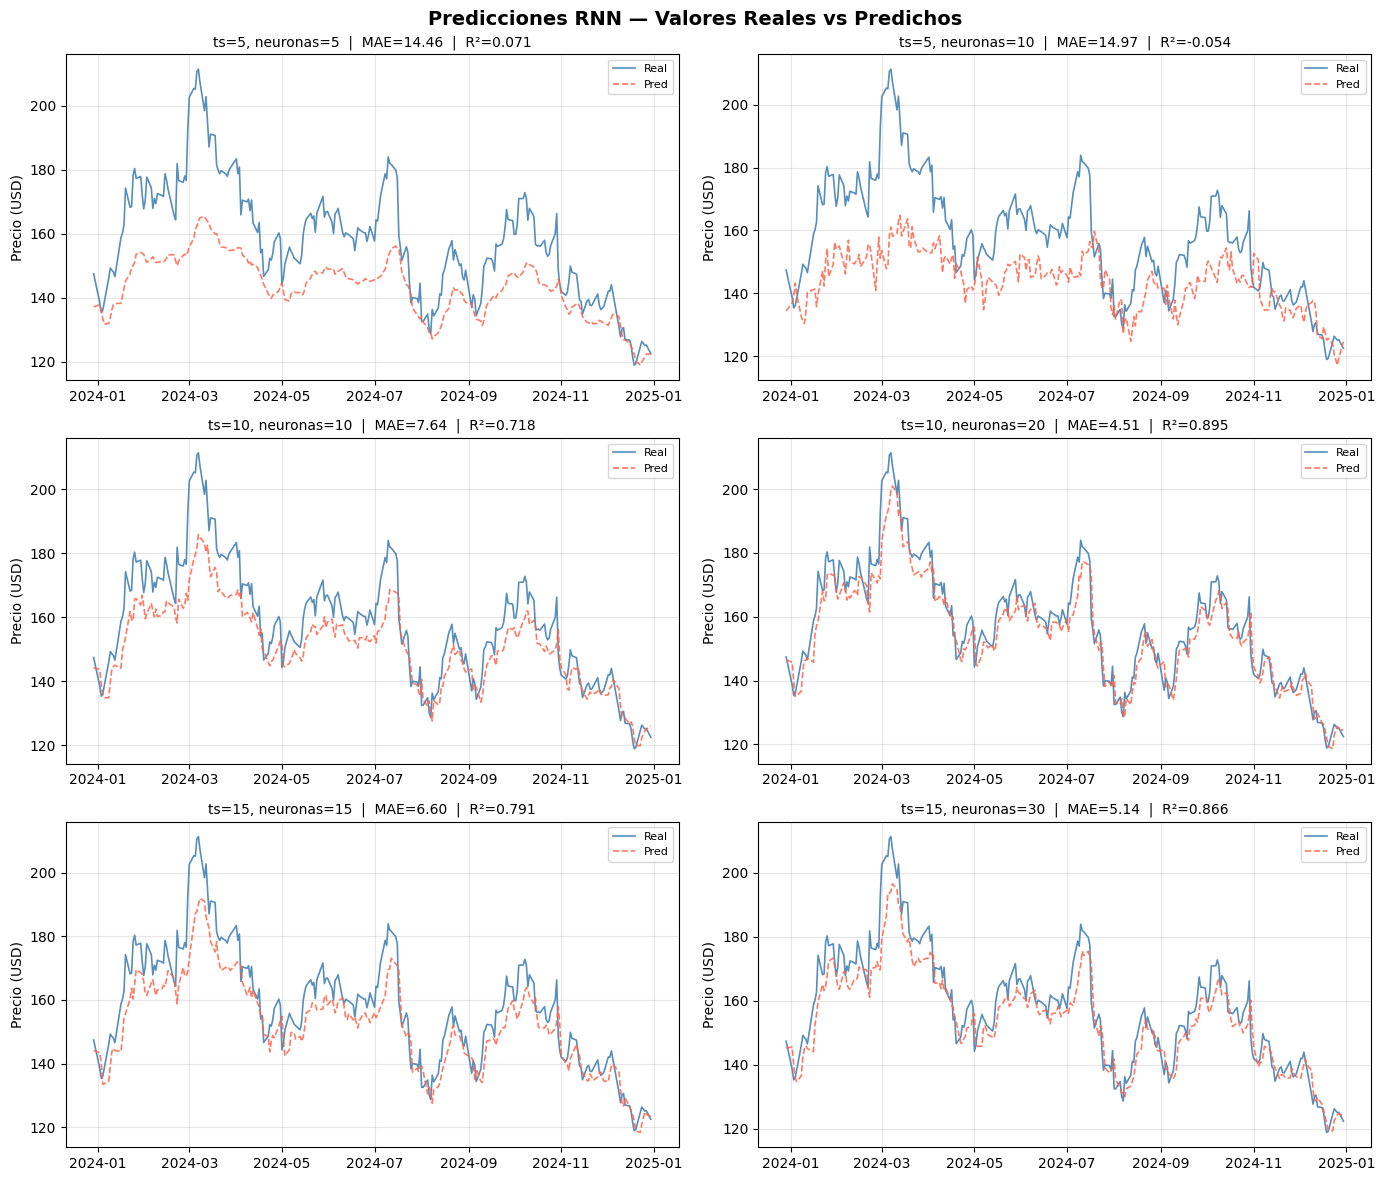

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Predicciones RNN — Valores Reales vs Predichos', fontsize=14, fontweight='bold')

for idx, (ts, u) in enumerate(CONFIGS):
    ax  = axes[idx // 2][idx % 2]
    key = f"SimpleRNN_ts{ts}_u{u}"
    p   = all_preds[key]
    row = results_df[(results_df['Modelo']=='SimpleRNN') &
                     (results_df['time_step']==ts) &
                     (results_df['Neuronas']==u)].iloc[0]

    ax.plot(p['dates'], p['y_real'], color='steelblue', lw=1.2, label='Real',   alpha=0.9)
    ax.plot(p['dates'], p['y_pred'], color='tomato',    lw=1.2, label='Pred',   alpha=0.85, ls='--')
    ax.set_title(f"ts={ts}, neuronas={u}  |  MAE={row.MAE:.2f}  |  R²={row.R2:.3f}", fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylabel("Precio (USD)")

plt.tight_layout()
plt.savefig("fig2_pred_simplernn.png", dpi=150, bbox_inches='tight')
plt.show()


### 8.2 Predicciones — LSTM

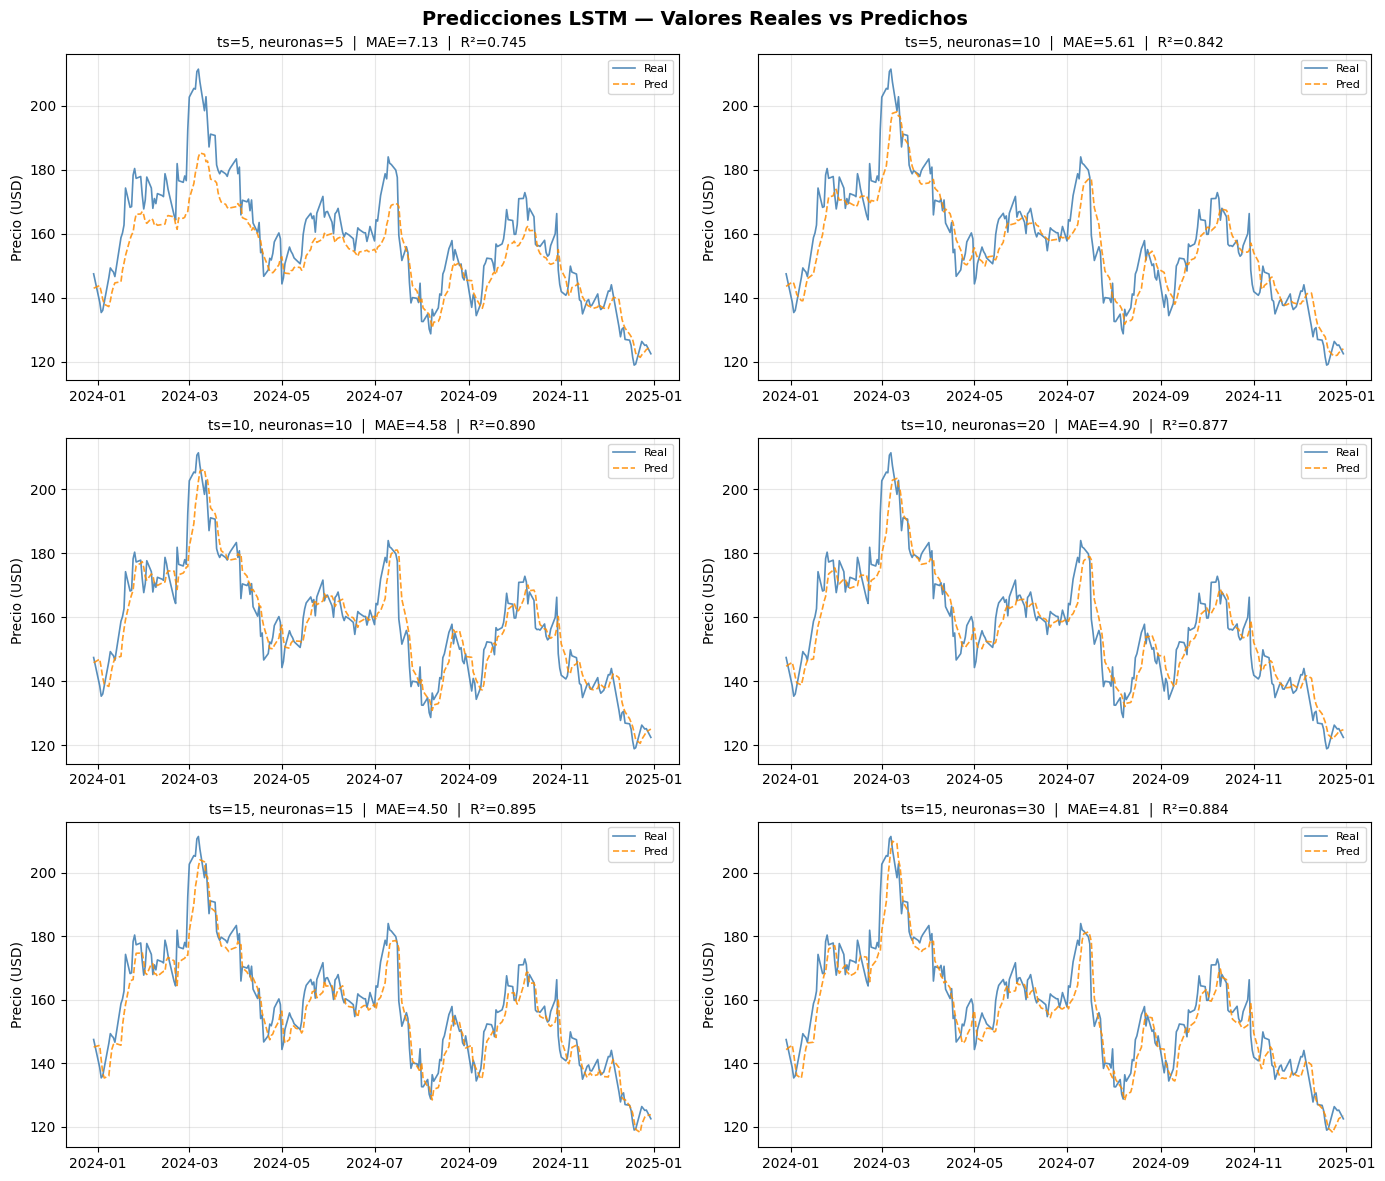

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Predicciones LSTM — Valores Reales vs Predichos', fontsize=14, fontweight='bold')

for idx, (ts, u) in enumerate(CONFIGS):
    ax  = axes[idx // 2][idx % 2]
    key = f"LSTM_ts{ts}_u{u}"
    p   = all_preds[key]
    row = results_df[(results_df['Modelo']=='LSTM') &
                     (results_df['time_step']==ts) &
                     (results_df['Neuronas']==u)].iloc[0]

    ax.plot(p['dates'], p['y_real'], color='steelblue',  lw=1.2, label='Real', alpha=0.9)
    ax.plot(p['dates'], p['y_pred'], color='darkorange', lw=1.2, label='Pred', alpha=0.85, ls='--')
    ax.set_title(f"ts={ts}, neuronas={u}  |  MAE={row.MAE:.2f}  |  R²={row.R2:.3f}", fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_ylabel("Precio (USD)")

plt.tight_layout()
plt.savefig("fig3_pred_lstm.png", dpi=150, bbox_inches='tight')
plt.show()


### 8.3 Curvas de Pérdida — SimpleRNN

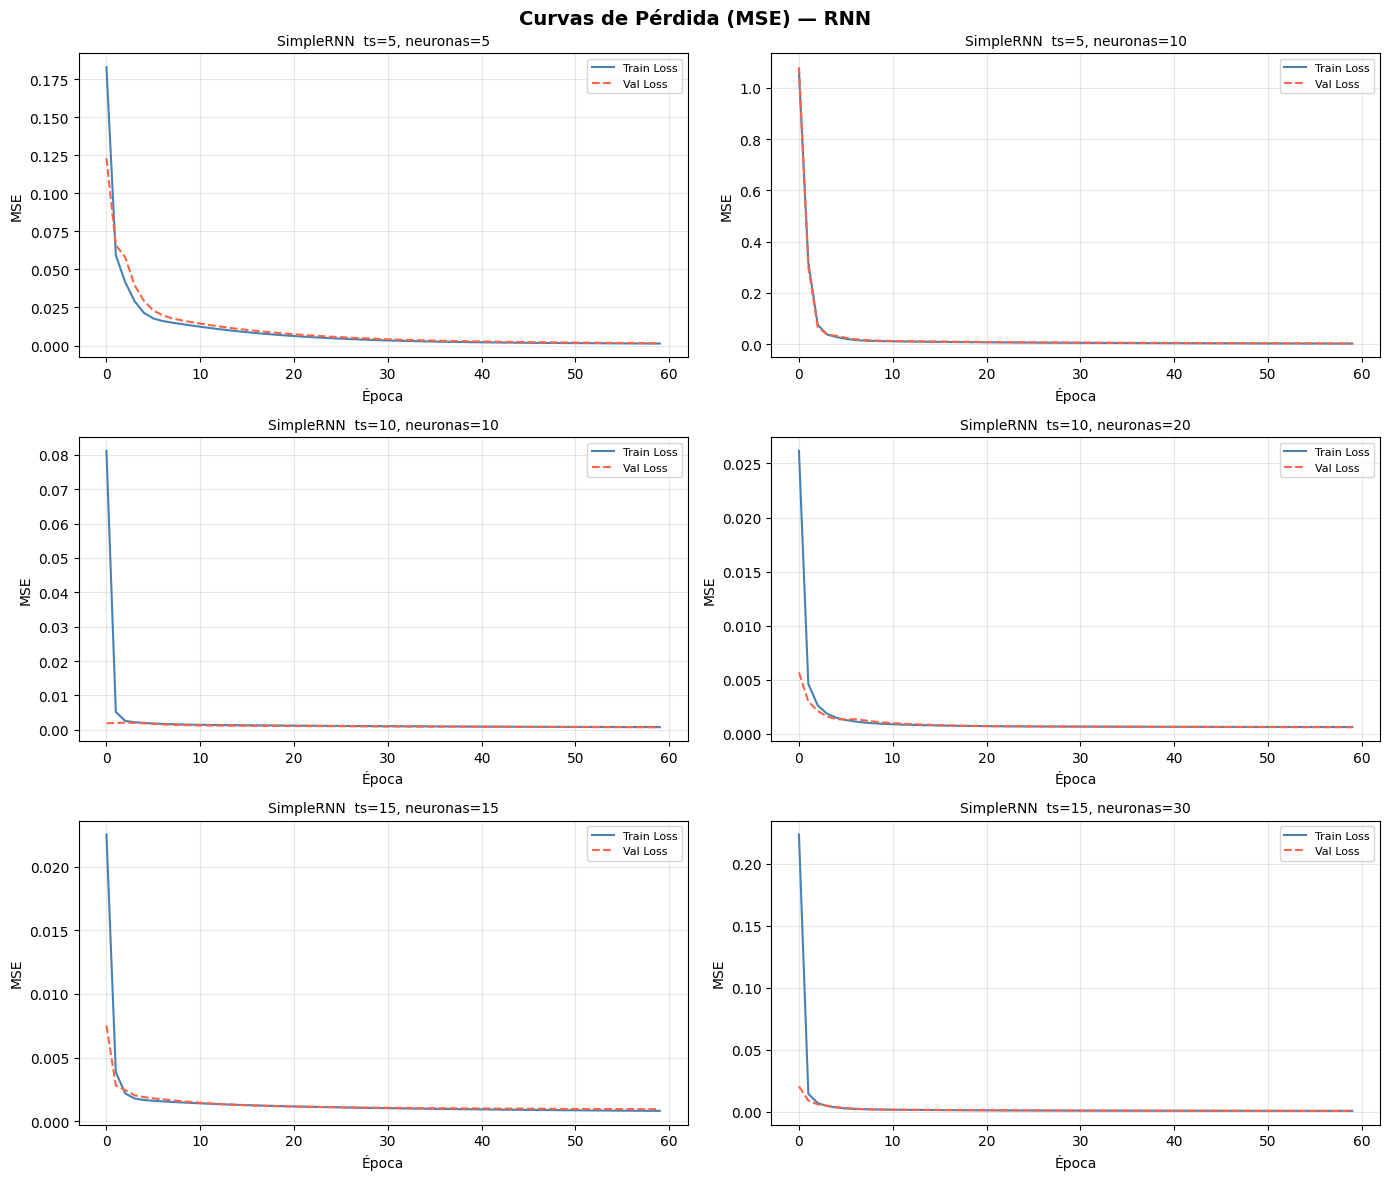

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Curvas de Pérdida (MSE) — RNN', fontsize=14, fontweight='bold')

for idx, (ts, u) in enumerate(CONFIGS):
    ax  = axes[idx // 2][idx % 2]
    key = f"SimpleRNN_ts{ts}_u{u}"
    h   = all_histories[key]
    ax.plot(h['loss'],     color='steelblue', lw=1.5, label='Train Loss')
    ax.plot(h['val_loss'], color='tomato',    lw=1.5, label='Val Loss', ls='--')
    ax.set_title(f"SimpleRNN  ts={ts}, neuronas={u}", fontsize=10)
    ax.set_xlabel("Época"); ax.set_ylabel("MSE")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig4_loss_simplernn.png", dpi=150, bbox_inches='tight')
plt.show()


### 8.4 Curvas de Pérdida — LSTM

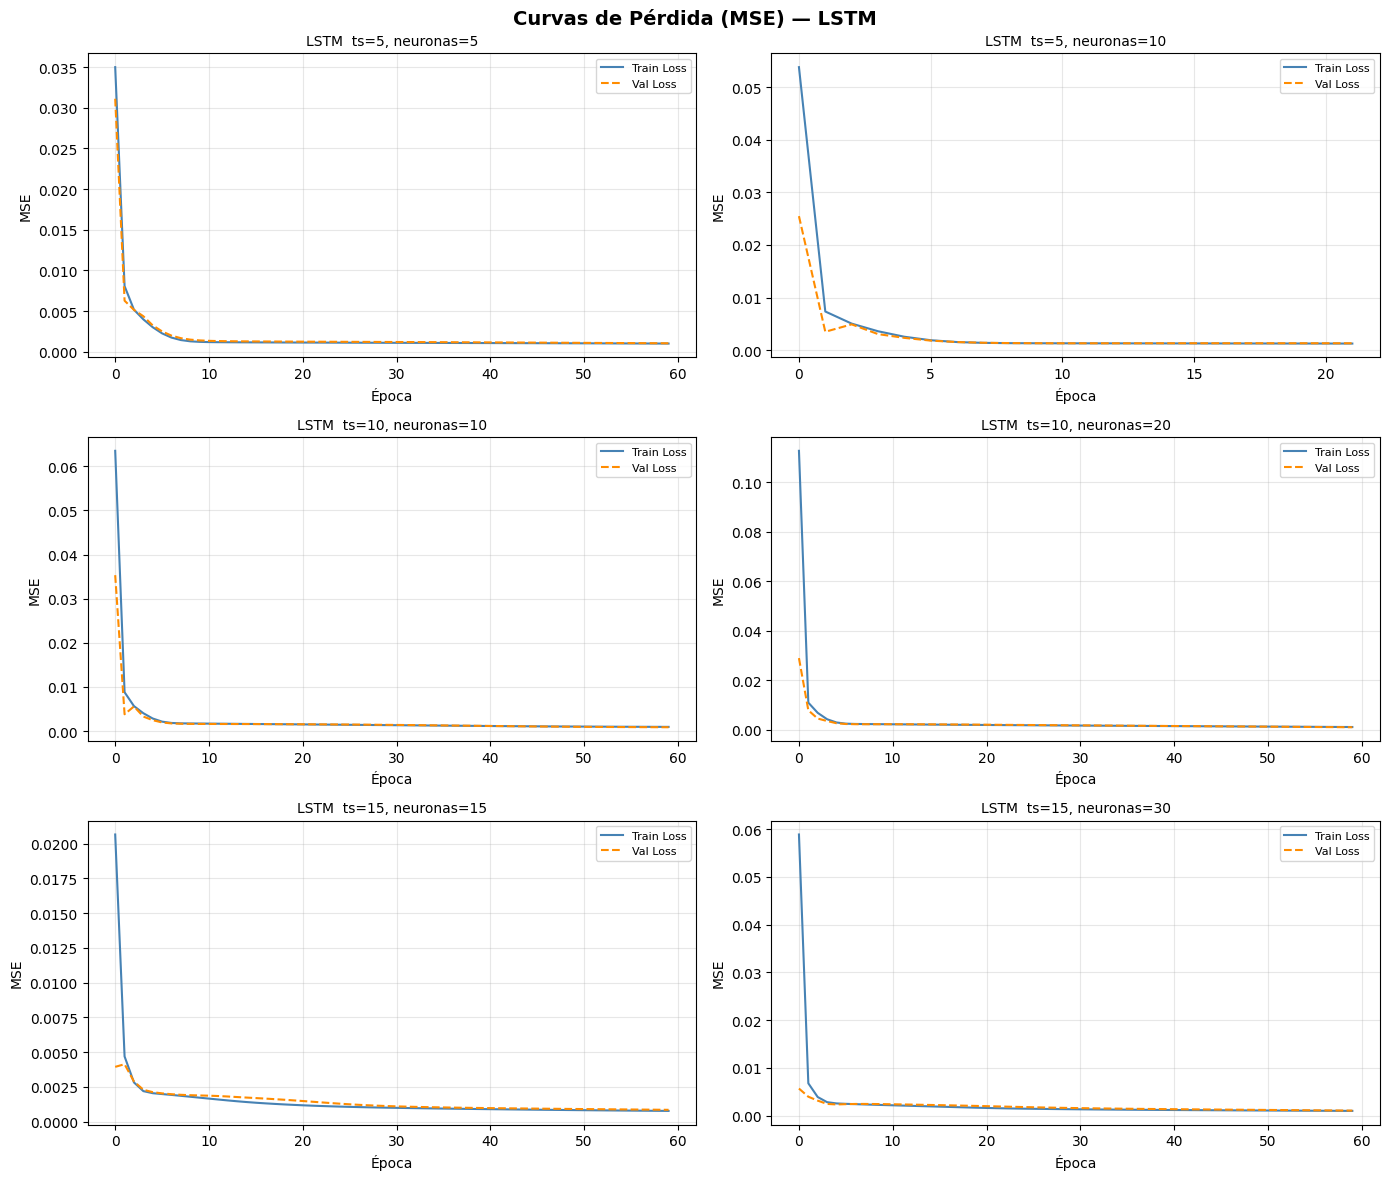

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Curvas de Pérdida (MSE) — LSTM', fontsize=14, fontweight='bold')

for idx, (ts, u) in enumerate(CONFIGS):
    ax  = axes[idx // 2][idx % 2]
    key = f"LSTM_ts{ts}_u{u}"
    h   = all_histories[key]
    ax.plot(h['loss'],     color='steelblue',   lw=1.5, label='Train Loss')
    ax.plot(h['val_loss'], color='darkorange',   lw=1.5, label='Val Loss', ls='--')
    ax.set_title(f"LSTM  ts={ts}, neuronas={u}", fontsize=10)
    ax.set_xlabel("Época"); ax.set_ylabel("MSE")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig5_loss_lstm.png", dpi=150, bbox_inches='tight')
plt.show()


### 8.5 Comparativa Final — MAE y R²

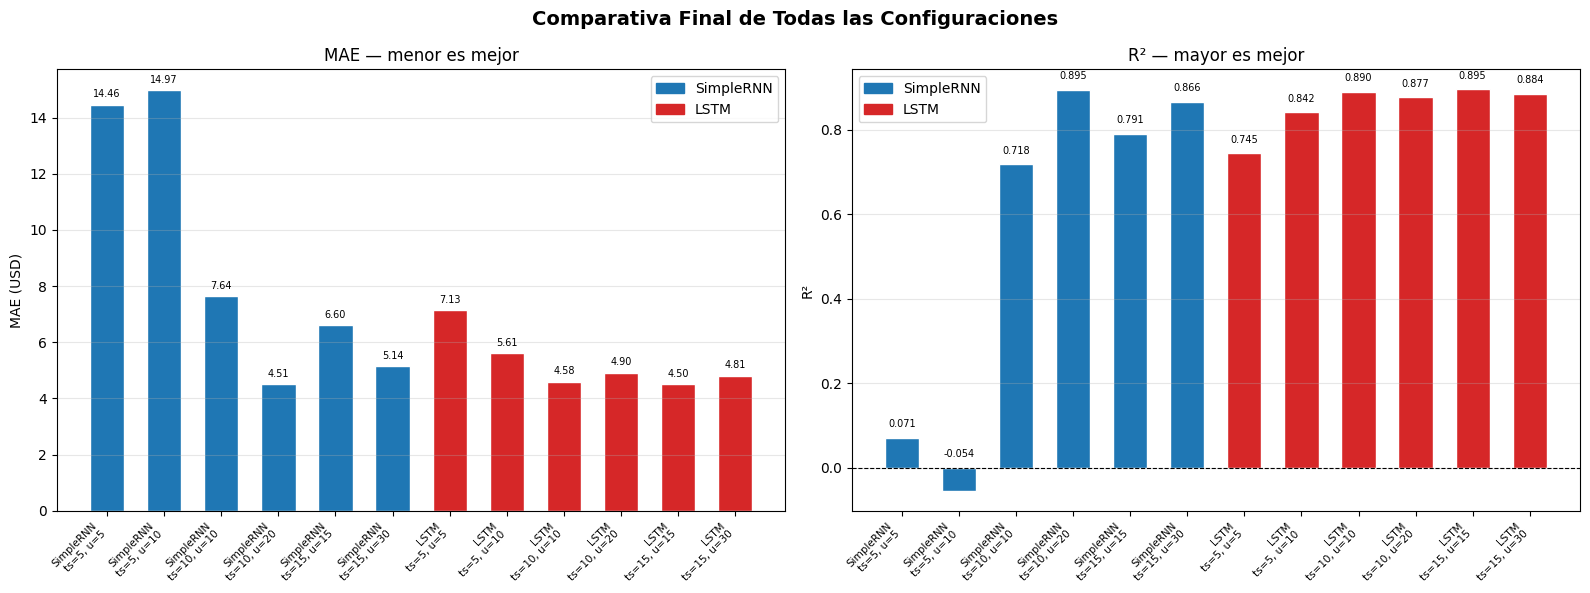

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparativa Final de Todas las Configuraciones', fontsize=14, fontweight='bold')

labels = [f"{r['Modelo']}\nts={r['time_step']}, u={r['Neuronas']}"
          for _, r in results_df.iterrows()]
colors = ['#1f77b4' if r['Modelo']=='SimpleRNN' else '#d62728'
          for _, r in results_df.iterrows()]
x = np.arange(len(labels))

# MAE
bars1 = ax1.bar(x, results_df['MAE'], color=colors, width=0.6, edgecolor='white')
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=7.5, rotation=45, ha='right')
ax1.set_ylabel('MAE (USD)'); ax1.set_title('MAE — menor es mejor')
ax1.grid(axis='y', alpha=0.3)
for bar, v in zip(bars1, results_df['MAE']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{v:.2f}', ha='center', va='bottom', fontsize=7)

# R²
r2_vis = results_df['R2'].clip(lower=-1)   # recortar outliers extremos para visualización
bars2 = ax2.bar(x, r2_vis, color=colors, width=0.6, edgecolor='white')
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=7.5, rotation=45, ha='right')
ax2.set_ylabel('R²'); ax2.set_title('R² — mayor es mejor')
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.grid(axis='y', alpha=0.3)
for bar, v in zip(bars2, results_df['R2']):
    ax2.text(bar.get_x()+bar.get_width()/2, max(bar.get_height(), 0)+0.02,
             f'{v:.3f}', ha='center', va='bottom', fontsize=7)

leg_patches = [mpatches.Patch(color='#1f77b4', label='SimpleRNN'),
               mpatches.Patch(color='#d62728', label='LSTM')]
ax1.legend(handles=leg_patches); ax2.legend(handles=leg_patches)

plt.tight_layout()
plt.savefig("fig6_comparativa_final.png", dpi=150, bbox_inches='tight')
plt.show()


# 9. Conclusiones

**Las ventanas cortas (ts=5) fueron un problema para SimpleRNN.** Los dos peores modelos del experimento son SimpleRNN con ts=5, con MAE por encima de 14 y un R² prácticamente de cero (−0.054 significa que predice peor que usar simplemente el promedio histórico). Con tan pocos días de contexto, la RNN simple no logra capturar ningún patrón útil.

**La ventana media (ts=10) fue la zona más consistente.** Tres de los cinco mejores modelos usan ts=10. Ni tan corta que el modelo no vea suficiente historia, ni tan larga que le cueste aprender. Funcionó bien tanto para LSTM como para SimpleRNN.

**Más neuronas no siempre fue mejor.** Sorprendentemente, LSTM ts=15 con 15 neuronas superó a LSTM ts=15 con 30 neuronas (MAE 4.50 vs 4.81). Lo mismo pasó con SimpleRNN ts=10: la versión de 20 neuronas fue mejor que la de 10, pero LSTM ts=10 con 10 neuronas (la más pequeña) quedó tercera en el ranking general. Esto sugiere que con más neuronas algunos modelos empezaron a sobreajustarse.

**LSTM fue más consistente que SimpleRNN en general.** Los 5 modelos LSTM quedaron todos entre los puestos 1 y 9, mientras que los 2 peores del experimento son SimpleRNN. Sin embargo, SimpleRNN ts=10/u=20 logró empatar con el mejor LSTM, lo que muestra que cuando la configuración es la adecuada, la brecha desaparece.

---

En pocas palabras: **los ganadores no fueron los modelos más grandes ni los que miraron más lejos, sino los que encontraron el balance justo entre contexto y capacidad.** El experimento muestra que en series financieras, más no siempre es mejor, y que la elección del `time_step` es tan o más importante que la arquitectura elegida.